# Day 5 — EDA Part 2: Correlation & Data Storytelling

This notebook completes the Day 5 EDA workflow using the OBD-II dataset.
It includes data loading, cleaning, numeric feature selection, bivariate analysis, correlation analysis, pairplot scanning, and storytelling conclusions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../OBDii_data.csv")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 60439 entries, 0 to 60438
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TIMESTAMP                    47514 non-null  float64
 1   MARK                         47459 non-null  str    
 2   MODEL                        47459 non-null  str    
 3   CAR_YEAR                     47459 non-null  float64
 4   ENGINE_POWER                 47459 non-null  str    
 5   AUTOMATIC                    47459 non-null  str    
 6   VEHICLE_ID                   47514 non-null  str    
 7   BAROMETRIC_PRESSURE(KPA)     10212 non-null  float64
 8   ENGINE_COOLANT_TEMP          33964 non-null  float64
 9   FUEL_LEVEL                   2994 non-null   str    
 10  ENGINE_LOAD                  30972 non-null  str    
 11  AMBIENT_AIR_TEMP             3619 non-null   float64
 12  ENGINE_RPM                   33859 non-null  float64
 13  INTAKE_MANIFOLD_PRESSURE   

/tmp/ipykernel_578842/289021236.py:6: DtypeWarning: Columns (0: MARK, 1: MODEL, 2: ENGINE_POWER, 3: AUTOMATIC, 4: VEHICLE_ID, 5: FUEL_LEVEL, 6: ENGINE_LOAD, 7: MAF, 8: LONG TERM FUEL TRIM BANK 2, 9: FUEL_TYPE, 10: SHORT TERM FUEL TRIM BANK 2, 11: SHORT TERM FUEL TRIM BANK 1, 12: ENGINE_RUNTIME, 13: THROTTLE_POS, 14: DTC_NUMBER, 15: TROUBLE_CODES, 16: TIMING_ADVANCE, 17: EQUIV_RATIO) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../OBDii_data.csv")


## Data cleaning

Drop rows and columns that are completely empty, then verify the remaining missing values.

In [68]:
df.isna().sum()
df.dropna(how='all', inplace=True)
df.dropna(how='all', axis=1, inplace=True)
print(df.isna().sum())

TIMESTAMP                          0
MARK                              55
MODEL                             55
CAR_YEAR                          55
ENGINE_POWER                      55
AUTOMATIC                         55
VEHICLE_ID                         0
BAROMETRIC_PRESSURE(KPA)       37302
ENGINE_COOLANT_TEMP            13550
FUEL_LEVEL                     44520
ENGINE_LOAD                    16542
AMBIENT_AIR_TEMP               43895
ENGINE_RPM                     13655
INTAKE_MANIFOLD_PRESSURE       22425
MAF                            35686
LONG TERM FUEL TRIM BANK 2     34444
FUEL_TYPE                      27509
AIR_INTAKE_TEMP                13162
FUEL_PRESSURE                  47376
SPEED                            985
SHORT TERM FUEL TRIM BANK 2    34444
SHORT TERM FUEL TRIM BANK 1     9919
ENGINE_RUNTIME                 35612
THROTTLE_POS                   13655
DTC_NUMBER                       372
TROUBLE_CODES                  35589
TIMING_ADVANCE                 13352
E

## Select numeric columns

Use the numeric-only subset for correlation, pairplots, and many of the EDA charts.

In [69]:
filtered_df = df.select_dtypes(include=["number"])
filtered_df.drop("FUEL_PRESSURE", axis=1, inplace=True)
print(filtered_df)

titles = filtered_df.columns.tolist()
print(titles)

          TIMESTAMP  CAR_YEAR  BAROMETRIC_PRESSURE(KPA)  ENGINE_COOLANT_TEMP  \
0      1.502903e+12    2011.0                     100.0                 80.0   
1      1.502903e+12    2011.0                     100.0                 80.0   
2      1.502903e+12    2011.0                     100.0                 80.0   
3      1.502903e+12    2011.0                     100.0                 80.0   
4      1.502903e+12    2011.0                     100.0                 80.0   
...             ...       ...                       ...                  ...   
47509  1.503276e+12    2013.0                       NaN                 96.0   
47510  1.503276e+12    2013.0                       NaN                 96.0   
47511  1.503276e+12    2013.0                       NaN                 98.0   
47512  1.503276e+12    2013.0                       NaN                 99.0   
47513  1.503276e+12    2013.0                       NaN                100.0   

       AMBIENT_AIR_TEMP  ENGINE_RPM  IN

## Bivariate analysis

Scatter plots and box plots reveal relationships between variables and help find patterns.

<Axes: xlabel='ENGINE_RPM'>

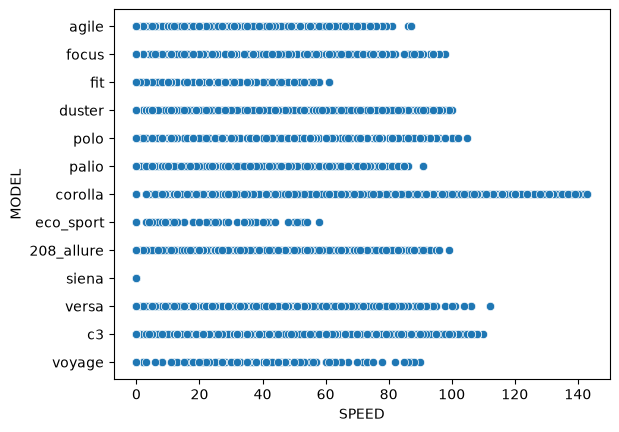

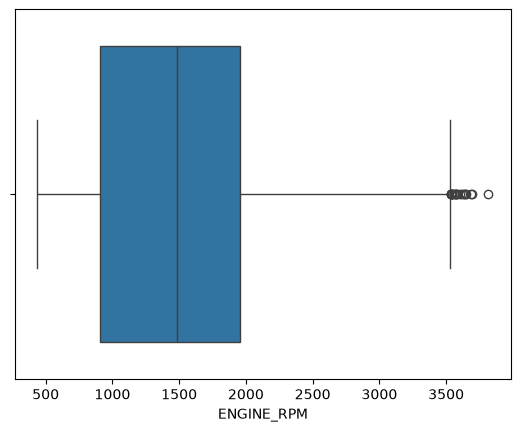

In [70]:
sns.scatterplot(x='SPEED', y='MODEL', data=df)

plt.figure()
sns.boxplot(data=filtered_df, x='ENGINE_RPM')

## Correlation matrix

Compute the correlation matrix for numeric features, and visualize it as an annotated heatmap.

<Axes: >

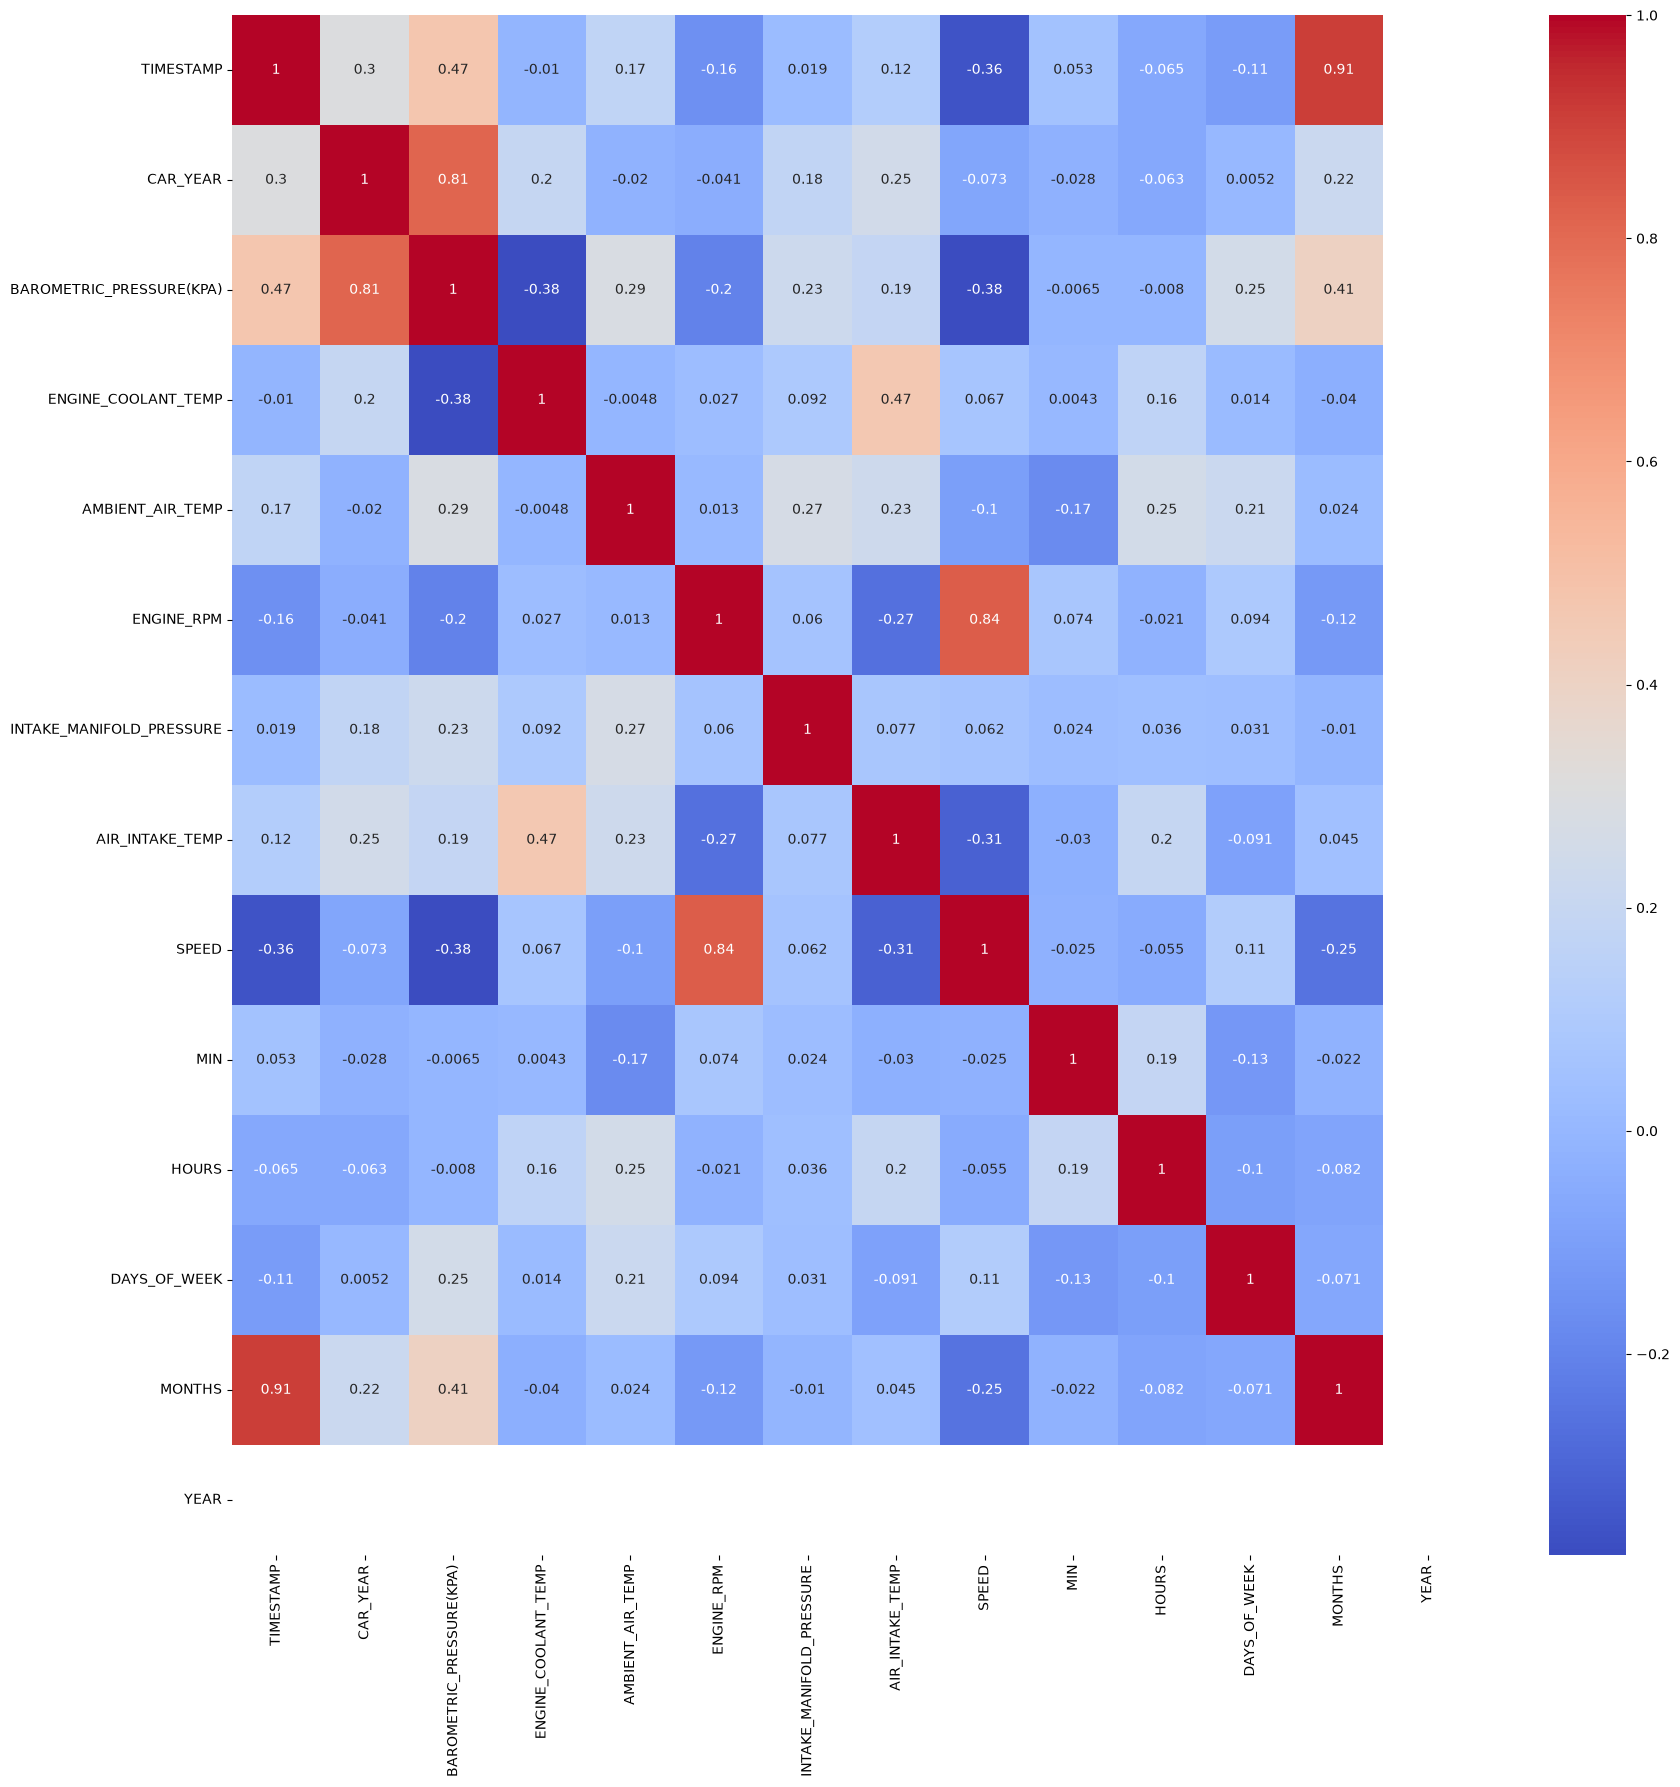

In [71]:
plt.figure(figsize=(20, 20))
cor = filtered_df.corr()
sns.heatmap(cor, annot=True, cmap="coolwarm")

## Pairplot

Scan the selected numeric features together with a pairplot to see how they relate.

<Figure size 1600x1000 with 0 Axes>

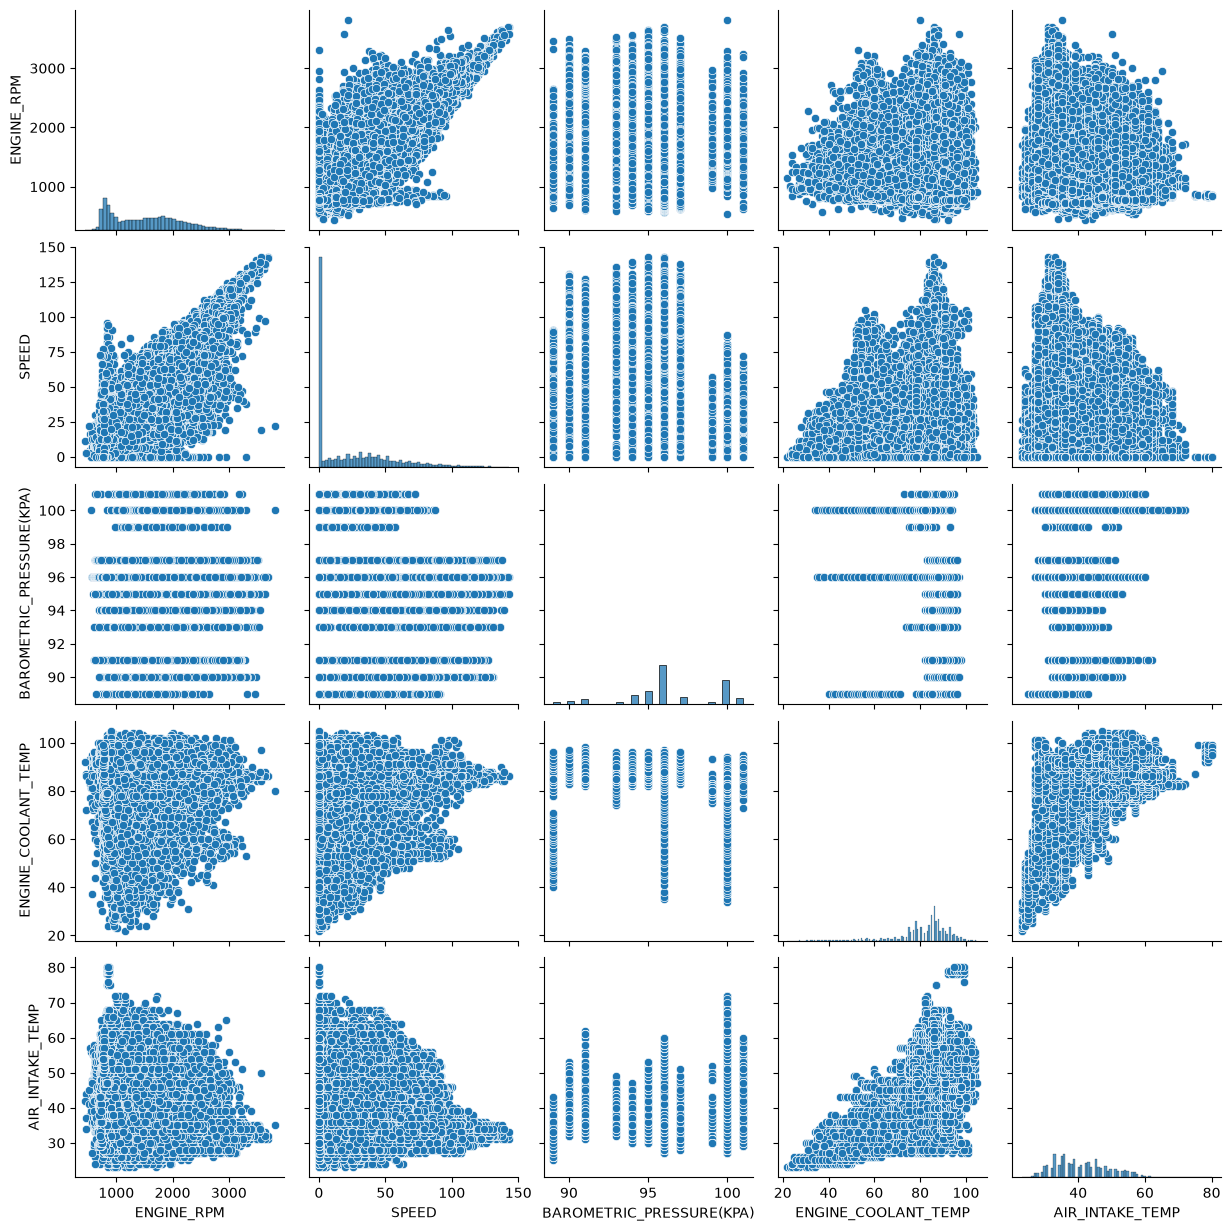

In [72]:
plt.figure(figsize=(16, 10))
sns.pairplot(filtered_df[[
    "ENGINE_RPM",
    "SPEED",
    "BAROMETRIC_PRESSURE(KPA)",
    "ENGINE_COOLANT_TEMP",
    "AIR_INTAKE_TEMP"
]])

## Findings and storytelling

- `ENGINE_RPM` and `SPEED` show a clear relationship.
- The heatmap highlights which numeric features move together most strongly.
- The pairplot helps confirm whether relationships are linear and whether outliers exist.
- Remember: correlation is not causation — these charts reveal relationships, not proof of cause.
- For modeling, focus on strong numeric relationships and note any features with outliers or weak correlation.